In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "german_credit_data.csv"  # AJUSTE al nombre real que le salió en el listado

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "uciml/german-credit",
    file_path,
)

print(df.head())
print(df.shape)
print(df.columns)


C:\Users\Esteban Orozco G\AppData\Local\Temp\ipykernel_43416\1660803757.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  
(1000, 10)
Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='str')


In [2]:
import os

os.makedirs("data/raw", exist_ok=True)
df.to_csv("data/raw/german_credit.csv", index=False)

#se realiza con el fin de tener un respaldo del dataset original y dejar de requerir la conexión a Kaggle para cargar el dataset en futuras ejecuciones del notebook.

In [3]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='str')

In [4]:
# Se observa que hay una columna "Unnamed: 0" que parece ser un índice. Se puede eliminar esta columna si no es necesaria para el análisis.
df = df.drop(columns=["Unnamed: 0"])

In [5]:
# extrae valores unicos de la columna housing
df["Housing"].unique()

<ArrowStringArray>
['own', 'free', 'rent']
Length: 3, dtype: str

In [6]:
df["Saving accounts"].value_counts()

Saving accounts
little        603
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

In [7]:
df["Credit amount"].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Credit amount, dtype: float64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
dtypes: int64(4), str(5)
memory usage: 95.9 KB


In [9]:
#nueva columna "Age_group" con rangos de edad
bins = [0, 25, 35, 45, 55, 65, np.inf]
labels = ["0-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df["Age_group"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [10]:
print(df["Age_group"].value_counts().sort_index())

Age_group
0-25     190
26-35    398
36-45    226
46-55    115
56-65     53
66+       18
Name: count, dtype: int64


In [11]:
job_map = {
    0: "desempleado",
    1: "no cualificado",
    2: "cualificado",
    3: "muy cualificado"
}
df["Job_type"] = df["Job"].map(job_map)
print(df["Job_type"].value_counts().sort_index())

Job_type
cualificado        630
desempleado         22
muy cualificado    148
no cualificado     200
Name: count, dtype: int64


In [12]:
df["Purpose"].value_counts()

Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

In [13]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Age_group', 'Job_type'],
      dtype='str')

In [14]:
df["Duration"].describe()

count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: Duration, dtype: float64

In [15]:
bins = [0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, np.inf]
labels = ["0-6", "7-12", "13-18", "19-24", "25-30", "31-36", "37-42", "43-48", "49-54",
          "55-60", "61-66", "67-72", "73+"]
df["Duration_estimated"] = pd.cut(df["Duration"], bins=bins, labels=labels)

In [16]:
df['Duration_estimated'].value_counts().sort_index()

Duration_estimated
0-6       82
7-12     277
13-18    187
19-24    224
25-30     57
31-36     86
37-42     17
43-48     54
49-54      2
55-60     13
61-66      0
67-72      1
73+        0
Name: count, dtype: int64

In [17]:
orden_job = ["desempleado", "no cualificado", "cualificado", "muy cualificado"]
job_duration = (df.groupby("Job_type")["Duration_estimated"]
      .value_counts()
      .unstack(fill_value=0)
      .reindex(orden_job)
)

job_duration



Duration_estimated,0-6,7-12,13-18,19-24,25-30,31-36,37-42,43-48,49-54,55-60,61-66,67-72,73+
Job_type,,,,,,,,,,,,,
desempleado,5,5,7,2,0,1,1,1,0,0,0,0,0
no cualificado,25,83,32,38,9,5,1,5,1,1,0,0,0
cualificado,43,162,128,147,35,58,11,38,1,6,0,1,0
muy cualificado,9,27,20,37,13,22,4,10,0,6,0,0,0


In [18]:
# Tabla de frecuencias (conteos)
tabla_sa_ca = pd.crosstab(
    df["Saving accounts"].fillna("No_tiene"),
    df["Checking account"].fillna("No_tiene")
)

tabla_sa_ca


Checking account,No_tiene,little,moderate,rich
Saving accounts,,,,
No_tiene,99,29,45,10
little,191,219,152,41
moderate,39,12,47,5
quite rich,40,8,11,4
rich,25,6,14,3


In [19]:
tabla_sa_ca_pct = pd.crosstab(
    df["Saving accounts"].fillna("No_tiene"),
    df["Checking account"].fillna("No_tiene"),
    normalize="columns"
).round(3)

print(tabla_sa_ca_pct)


Checking account  No_tiene  little  moderate   rich
Saving accounts                                    
No_tiene             0.251   0.106     0.167  0.159
little               0.485   0.799     0.565  0.651
moderate             0.099   0.044     0.175  0.079
quite rich           0.102   0.029     0.041  0.063
rich                 0.063   0.022     0.052  0.048


In [20]:
df["Financial_profile"] = df["Saving accounts"].fillna("No_tiene") + " / " + df["Checking account"].fillna("No_tiene")
print(df["Financial_profile"].value_counts())

Financial_profile
little / little          219
little / No_tiene        191
little / moderate        152
No_tiene / No_tiene       99
moderate / moderate       47
No_tiene / moderate       45
little / rich             41
quite rich / No_tiene     40
moderate / No_tiene       39
No_tiene / little         29
rich / No_tiene           25
rich / moderate           14
moderate / little         12
quite rich / moderate     11
No_tiene / rich           10
quite rich / little        8
rich / little              6
moderate / rich            5
quite rich / rich          4
rich / rich                3
Name: count, dtype: int64


In [21]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Age_group', 'Job_type',
       'Duration_estimated', 'Financial_profile'],
      dtype='str')

In [22]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Age_group,Job_type,Duration_estimated,Financial_profile
0,67,male,2,own,NaN,little,1169,6,radio/TV,66+,cualificado,0-6,No_tiene / little
1,22,female,2,own,little,moderate,5951,48,radio/TV,0-25,cualificado,43-48,little / moderate
2,49,male,1,own,little,NaN,2096,12,education,46-55,no cualificado,7-12,little / No_tiene
3,45,male,2,free,little,little,7882,42,furniture/equipment,36-45,cualificado,37-42,little / little
4,53,male,2,free,little,little,4870,24,car,46-55,cualificado,19-24,little / little
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,26-35,no cualificado,7-12,little / No_tiene
996,40,male,3,own,little,little,3857,30,car,36-45,muy cualificado,25-30,little / little
997,38,male,2,own,little,NaN,804,12,radio/TV,36-45,cualificado,7-12,little / No_tiene
998,23,male,2,free,little,little,1845,45,radio/TV,0-25,cualificado,43-48,little / little


In [23]:
df['Purpose'].value_counts()

Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

In [24]:
Risk_map = {
    'car': 'bajo riesgo',
    'radio/TV': 'alto riesgo',
    'furniture/equipment': 'medio riesgo',
    'business': 'medio riesgo',
    'education': 'bajo riesgo',
    'repairs': 'medio riesgo',
    'domestic appliances': 'medio riesgo',
    'vacation/others': 'alto riesgo'
}

df["Risk_per_purpose"] = df["Purpose"].map(Risk_map)

print(df["Risk_per_purpose"].value_counts().sort_index())
Riesgo_por_purpose = (
    df.groupby("Purpose")["Risk_per_purpose"]
      .value_counts(normalize=True)
      .unstack(fill_value=0)
      .round(3)
)
print(Riesgo_por_purpose)



Risk_per_purpose
alto riesgo     292
bajo riesgo     396
medio riesgo    312
Name: count, dtype: int64
Risk_per_purpose     alto riesgo  bajo riesgo  medio riesgo
Purpose                                                    
business                     0.0          0.0           1.0
car                          0.0          1.0           0.0
domestic appliances          0.0          0.0           1.0
education                    0.0          1.0           0.0
furniture/equipment          0.0          0.0           1.0
radio/TV                     1.0          0.0           0.0
repairs                      0.0          0.0           1.0
vacation/others              1.0          0.0           0.0


In [25]:
df.drop(columns=["Age","Job"], inplace=True)

In [26]:
df

,Sex,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Age_group,Job_type,Duration_estimated,Financial_profile,Risk_per_purpose
0,male,own,NaN,little,1169,6,radio/TV,66+,cualificado,0-6,No_tiene / little,alto riesgo
1,female,own,little,moderate,5951,48,radio/TV,0-25,cualificado,43-48,little / moderate,alto riesgo
2,male,own,little,NaN,2096,12,education,46-55,no cualificado,7-12,little / No_tiene,bajo riesgo
3,male,free,little,little,7882,42,furniture/equipment,36-45,cualificado,37-42,little / little,medio riesgo
4,male,free,little,little,4870,24,car,46-55,cualificado,19-24,little / little,bajo riesgo
...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,own,little,NaN,1736,12,furniture/equipment,26-35,no cualificado,7-12,little / No_tiene,medio riesgo
996,male,own,little,little,3857,30,car,36-45,muy cualificado,25-30,little / little,bajo riesgo
997,male,own,little,NaN,804,12,radio/TV,36-45,cualificado,7-12,little / No_tiene,alto riesgo
998,male,free,little,little,1845,45,radio/TV,0-25,cualificado,43-48,little / little,alto riesgo


In [27]:
orden = [
     'Sex', 'Age_group', 'Housing','Purpose', 'Risk_per_purpose', 'Credit amount', 'Duration',
    'Financial_profile', 'Saving accounts', 'Checking account',
    'Job_type', 'Duration_estimated'
]

df = df.reindex(columns=orden)


In [28]:
df

,Sex,Age_group,Housing,Purpose,Risk_per_purpose,Credit amount,Duration,Financial_profile,Saving accounts,Checking account,Job_type,Duration_estimated
0,male,66+,own,radio/TV,alto riesgo,1169,6,No_tiene / little,NaN,little,cualificado,0-6
1,female,0-25,own,radio/TV,alto riesgo,5951,48,little / moderate,little,moderate,cualificado,43-48
2,male,46-55,own,education,bajo riesgo,2096,12,little / No_tiene,little,NaN,no cualificado,7-12
3,male,36-45,free,furniture/equipment,medio riesgo,7882,42,little / little,little,little,cualificado,37-42
4,male,46-55,free,car,bajo riesgo,4870,24,little / little,little,little,cualificado,19-24
...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,26-35,own,furniture/equipment,medio riesgo,1736,12,little / No_tiene,little,NaN,no cualificado,7-12
996,male,36-45,own,car,bajo riesgo,3857,30,little / little,little,little,muy cualificado,25-30
997,male,36-45,own,radio/TV,alto riesgo,804,12,little / No_tiene,little,NaN,cualificado,7-12
998,male,0-25,free,radio/TV,alto riesgo,1845,45,little / little,little,little,cualificado,43-48


In [29]:
import os

out_dir = r"C:\data_sciences\GIT\Credit_risk\Credit_risk\data\raw"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "german_credit_processed.xlsx")
df.to_excel(out_path, index=False)

print(f"Archivo guardado en: {out_path}")


Archivo guardado en: C:\data_sciences\GIT\Credit_risk\Credit_risk\data\raw\german_credit_processed.xlsx


In [30]:
checking_map = {
    "rich": 0.00,
    "moderate": 0.50,
    "little": 0.75,
    "No_tiene": 1.00
}

df["Checking_score"] = (
    df["Checking account"]
      .fillna("No_tiene")
      .map(checking_map)
)

In [31]:
saving_map = {
    "rich": 0.00,
    "quite rich": 0.25,
    "moderate": 0.50,
    "little": 0.75,
    "No_tiene": 1.00
}
df["Saving_score"] = (
    df["Saving accounts"]
        .fillna("No_tiene")
        .map(saving_map)
)

In [32]:
df["Duration_score"] = (df["Duration"] / 72) ** 1.2
#a mayor duración, mayor riesgo, pero con una función de potencia para aumentar
# el impacto de duraciones largas.

In [33]:
job_map = {
    "desempleado": 1.00,
    "no cualificado": 0.60,
    "cualificado": 0.30,
    "muy cualificado": 0.00
}
df["Job_score"] = df["Job_type"].map(job_map)


In [34]:
risk_per_purpose_map = {
    "alto riesgo": 1.00,
    "medio riesgo": 0.50,
    "bajo riesgo": 0.00
}
df["Risk_per_purpose_score"] = df["Risk_per_purpose"].map(risk_per_purpose_map)

In [35]:
score = 0.0

# Monto
score += np.where(df["Credit amount"] > df["Credit amount"].median(), 1.0, 0.0)

# Plazo
score += df["Duration_score"]

# Liquidez
score += df["Saving_score"]
score += df["Checking_score"]

# Perfil laboral
score += df["Job_score"]

#riesgo por propósito
score += df["Risk_per_purpose_score"]

df["Internal_Risk_Score"] = score

In [36]:
df["PD_internal"] = df["Internal_Risk_Score"] / df["Internal_Risk_Score"].max()

In [37]:
df

,Sex,Age_group,Housing,Purpose,Risk_per_purpose,Credit amount,Duration,Financial_profile,Saving accounts,Checking account,Job_type,Duration_estimated,Checking_score,Saving_score,Duration_score,Job_score,Risk_per_purpose_score,Internal_Risk_Score,PD_internal
0,male,66+,own,radio/TV,alto riesgo,1169,6,No_tiene / little,NaN,little,cualificado,0-6,0.75,1.00,0.050697,0.3,1.0,3.100697,0.606228
1,female,0-25,own,radio/TV,alto riesgo,5951,48,little / moderate,little,moderate,cualificado,43-48,0.50,0.75,0.614739,0.3,1.0,4.164739,0.814262
2,male,46-55,own,education,bajo riesgo,2096,12,little / No_tiene,little,NaN,no cualificado,7-12,1.00,0.75,0.116471,0.6,0.0,2.466471,0.482228
3,male,36-45,free,furniture/equipment,medio riesgo,7882,42,little / little,little,little,cualificado,37-42,0.75,0.75,0.523721,0.3,0.5,3.823721,0.747589
4,male,46-55,free,car,bajo riesgo,4870,24,little / little,little,little,cualificado,19-24,0.75,0.75,0.267581,0.3,0.0,3.067581,0.599753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,26-35,own,furniture/equipment,medio riesgo,1736,12,little / No_tiene,little,NaN,no cualificado,7-12,1.00,0.75,0.116471,0.6,0.5,2.966471,0.579985
996,male,36-45,own,car,bajo riesgo,3857,30,little / little,little,little,muy cualificado,25-30,0.75,0.75,0.349741,0.0,0.0,2.849741,0.557163
997,male,36-45,own,radio/TV,alto riesgo,804,12,little / No_tiene,little,NaN,cualificado,7-12,1.00,0.75,0.116471,0.3,1.0,3.166471,0.619088
998,male,0-25,free,radio/TV,alto riesgo,1845,45,little / little,little,little,cualificado,43-48,0.75,0.75,0.568926,0.3,1.0,3.368926,0.658670


In [38]:
#descargar la tabla como csv
out_path_csv = os.path.join(out_dir, "german_credit_processed.csv")
df.to_csv(out_path_csv, index=False)

In [39]:
df['PD_internal'].describe()

count    1000.000000
mean        0.576891
std         0.153183
min         0.130304
25%         0.472453
50%         0.583063
75%         0.682237
max         1.000000
Name: PD_internal, dtype: float64

Text(0, 0.5, 'Frecuencia')

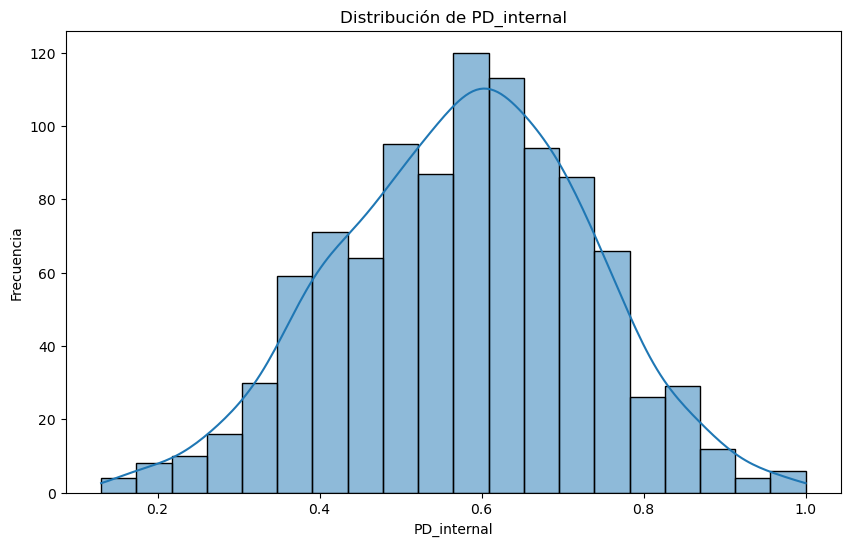

In [40]:
#plot de distribución de PD_internal
plt.figure(figsize=(10, 6))
sns.histplot(df['PD_internal'], bins=20, kde=True)
plt.title('Distribución de PD_internal')
plt.xlabel('PD_internal')
plt.ylabel('Frecuencia')
#podemos observar que la mayoría de los clientes tienen un PD_internal bajo,
# pero hay una cola hacia valores más altos, lo que indica que hay algunos clientes con un riesgo interno elevado.

## Modelo Supervisado Optimo (sin fuga)

Este flujo reemplaza la parte heuristica de `PD_internal` para decisiones de negocio.

Pasos:
1. Usar dataset con etiqueta real (`german.data-numeric`, target: `1=good`, `2=bad`).
2. Hacer split estratificado `train/valid/test`.
3. Entrenar regresion logistica solo en `train`.
4. Medir en `valid` (ROC-AUC, PR-AUC, Recall morosos, KS, matriz de confusion).
5. Ajustar umbrales de decision en `valid` minimizando costo (penalizando falso aprobado).
6. Reportar resultado final una sola vez en `test`.

Celdas legacy a dejar de usar para decision final:
- 23 (Risk_map manual por Purpose)
- 33 a 40 (score heuristico, `PD_internal` y decision por ese score)


In [41]:
import numpy as np
import pandas as pd
from pathlib import Path

# 1) Carga de dataset supervisado (tiene target real)
data_path = Path("data/raw/statlog+german+credit+data/german.data-numeric")
cols = [f"X{i}" for i in range(1, 25)] + ["target_raw"]
credit_ml = pd.read_csv(data_path, sep=r"\s+", header=None, names=cols)

# target_bad: 1 = bad/default, 0 = good
credit_ml["target_bad"] = (credit_ml["target_raw"] == 2).astype(int)

X = credit_ml[[f"X{i}" for i in range(1, 25)]].to_numpy(dtype=float)
y = credit_ml["target_bad"].to_numpy(dtype=int)

# 2) Split estratificado train/valid/test = 60/20/20
rng = np.random.default_rng(42)

idx_good = np.where(y == 0)[0]
idx_bad = np.where(y == 1)[0]
rng.shuffle(idx_good)
rng.shuffle(idx_bad)

def stratified_three_way(idxs, test_frac=0.2, valid_frac=0.2):
    n = len(idxs)
    n_test = int(round(n * test_frac))
    n_valid = int(round(n * valid_frac))
    test = idxs[:n_test]
    valid = idxs[n_test:n_test + n_valid]
    train = idxs[n_test + n_valid:]
    return train, valid, test

tr_g, va_g, te_g = stratified_three_way(idx_good, test_frac=0.2, valid_frac=0.2)
tr_b, va_b, te_b = stratified_three_way(idx_bad, test_frac=0.2, valid_frac=0.2)

train_idx = np.concatenate([tr_g, tr_b])
valid_idx = np.concatenate([va_g, va_b])
test_idx = np.concatenate([te_g, te_b])

rng.shuffle(train_idx)
rng.shuffle(valid_idx)
rng.shuffle(test_idx)

X_train, y_train = X[train_idx], y[train_idx]
X_valid, y_valid = X[valid_idx], y[valid_idx]
X_test, y_test = X[test_idx], y[test_idx]

print("Shapes -> train:", X_train.shape, "valid:", X_valid.shape, "test:", X_test.shape)
print("Bad rate -> train:", round(float(y_train.mean()), 4), "valid:", round(float(y_valid.mean()), 4), "test:", round(float(y_test.mean()), 4))


Shapes -> train: (600, 24) valid: (200, 24) test: (200, 24)
Bad rate -> train: 0.3 valid: 0.3 test: 0.3


In [42]:
# 3) Entrenamiento de regresion logistica (baseline interpretable) en numpy

def sigmoid(z):
    z = np.clip(z, -35, 35)
    return 1.0 / (1.0 + np.exp(-z))

def standardize_train_valid_test(X_tr, X_va, X_te):
    mu = X_tr.mean(axis=0)
    sigma = X_tr.std(axis=0)
    sigma[sigma == 0] = 1.0
    X_tr_s = (X_tr - mu) / sigma
    X_va_s = (X_va - mu) / sigma
    X_te_s = (X_te - mu) / sigma
    return X_tr_s, X_va_s, X_te_s

def log_loss(y_true, p):
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

def fit_logistic_gd(X_tr, y_tr, lr=0.05, n_iter=6000, l2=0.01, tol=1e-7):
    n, m = X_tr.shape
    Xb = np.column_stack([np.ones(n), X_tr])
    w = np.zeros(m + 1)
    prev_loss = np.inf

    for i in range(n_iter):
        p = sigmoid(Xb @ w)
        grad = (Xb.T @ (p - y_tr)) / n
        grad[1:] += (l2 / n) * w[1:]
        w -= lr * grad

        if i % 200 == 0:
            loss = log_loss(y_tr, p)
            if abs(prev_loss - loss) < tol:
                break
            prev_loss = loss

    return w

def predict_proba(X_, w):
    Xb = np.column_stack([np.ones(X_.shape[0]), X_])
    return sigmoid(Xb @ w)

X_train_s, X_valid_s, X_test_s = standardize_train_valid_test(X_train, X_valid, X_test)
weights = fit_logistic_gd(X_train_s, y_train)

pd_valid = predict_proba(X_valid_s, weights)
pd_test = predict_proba(X_test_s, weights)

print("PD promedio -> valid:", round(float(pd_valid.mean()), 4), "test:", round(float(pd_test.mean()), 4))


PD promedio -> valid: 0.3187 test: 0.3132


In [43]:
# 4) Metricas de clasificacion

def confusion_counts(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))
    return tp, fp, tn, fn

def roc_pr_ks(y_true, y_score):
    order = np.argsort(-y_score)
    ys = y_true[order]
    ss = y_score[order]

    P = max(int(np.sum(y_true == 1)), 1)
    N = max(int(np.sum(y_true == 0)), 1)

    tp = 0
    fp = 0
    tpr = [0.0]
    fpr = [0.0]
    precision = [1.0]
    recall = [0.0]

    prev = np.inf
    for yi, si in zip(ys, ss):
        if si != prev:
            tpr.append(tp / P)
            fpr.append(fp / N)
            precision.append(tp / (tp + fp) if (tp + fp) > 0 else 1.0)
            recall.append(tp / P)
            prev = si

        if yi == 1:
            tp += 1
        else:
            fp += 1

    tpr.append(1.0)
    fpr.append(1.0)
    precision.append(tp / (tp + fp) if (tp + fp) > 0 else 1.0)
    recall.append(1.0)

    roc_auc = float(np.trapezoid(tpr, fpr))
    rec = np.array(recall)
    pre = np.array(precision)
    ord_rec = np.argsort(rec)
    pr_auc = float(np.trapezoid(pre[ord_rec], rec[ord_rec]))
    ks = float(np.max(np.array(tpr) - np.array(fpr)))

    return roc_auc, pr_auc, ks

def evaluate_split(y_true, y_score, split_name, threshold=0.5):
    roc_auc, pr_auc, ks = roc_pr_ks(y_true, y_score)
    tp, fp, tn, fn = confusion_counts(y_true, y_score, threshold=threshold)
    recall_bad = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    print(f"[{split_name}] ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | KS: {ks:.4f} | Recall bad @{threshold:.2f}: {recall_bad:.4f}")

    cm = pd.DataFrame(
        [[tn, fp], [fn, tp]],
        index=["Real good (0)", "Real bad (1)"],
        columns=["Pred good (0)", "Pred bad (1)"]
    )
    return cm

cm_valid = evaluate_split(y_valid, pd_valid, split_name="VALID", threshold=0.50)
cm_test_baseline = evaluate_split(y_test, pd_test, split_name="TEST_BASELINE", threshold=0.50)

print("")
print("Matriz de confusion VALID")
cm_valid


[VALID] ROC-AUC: 0.7907 | PR-AUC: 0.5867 | KS: 0.4571 | Recall bad @0.50: 0.5333
[TEST_BASELINE] ROC-AUC: 0.7720 | PR-AUC: 0.5849 | KS: 0.4738 | Recall bad @0.50: 0.4500

Matriz de confusion VALID


,Pred good (0),Pred bad (1)
Real good (0),123,17
Real bad (1),28,32


In [44]:
# 5) Politica de decision y tuning de umbrales (SOLO en VALID)

def apply_policy(pd_values, t_auto=0.40, t_reject=0.55):
    decision = np.full(pd_values.shape[0], "Revision manual", dtype=object)
    decision[pd_values <= t_auto] = "Aprobado automatico"
    decision[pd_values >= t_reject] = "Rechazado"
    return decision

def policy_cost(
    y_true,
    pd_values,
    t_auto,
    t_reject,
    cost_false_approve=10.0,
    cost_false_reject=2.0,
    cost_manual=0.5,
):
    decision = apply_policy(pd_values, t_auto=t_auto, t_reject=t_reject)

    false_approve = int(np.sum((decision == "Aprobado automatico") & (y_true == 1)))
    false_reject = int(np.sum((decision == "Rechazado") & (y_true == 0)))
    manual = int(np.sum(decision == "Revision manual"))

    total_cost = (
        cost_false_approve * false_approve
        + cost_false_reject * false_reject
        + cost_manual * manual
    )

    return total_cost, false_approve, false_reject, manual

def policy_summary(y_true, pd_values, t_auto, t_reject):
    dec = apply_policy(pd_values, t_auto, t_reject)
    out = pd.DataFrame({"y_bad": y_true, "PD": pd_values, "Decision": dec})
    summary = (
        out.groupby("Decision")
        .agg(
            Clientes=("y_bad", "size"),
            Tasa_morosidad=("y_bad", "mean"),
            PD_promedio=("PD", "mean"),
        )
        .assign(Porcentaje=lambda d: d["Clientes"] / len(out))
        .sort_values("PD_promedio")
    )
    return summary

# Grid search de umbrales en VALID
rows = []
for t_auto in np.arange(0.15, 0.51, 0.01):
    for t_reject in np.arange(max(t_auto + 0.05, 0.40), 0.91, 0.01):
        cost, fa, fr, manual = policy_cost(
            y_valid,
            pd_valid,
            t_auto=float(np.round(t_auto, 2)),
            t_reject=float(np.round(t_reject, 2)),
            cost_false_approve=10.0,
            cost_false_reject=2.0,
            cost_manual=0.5,
        )
        rows.append((float(np.round(t_auto, 2)), float(np.round(t_reject, 2)), cost, fa, fr, manual))

valid_tuning = pd.DataFrame(
    rows,
    columns=["t_auto", "t_reject", "Costo_total", "Falsos_aprobados", "Falsos_rechazados", "Manual"],
).sort_values(["Costo_total", "Falsos_aprobados", "Falsos_rechazados"], ascending=[True, True, True])

best = valid_tuning.iloc[0]
best_t_auto = float(best["t_auto"])
best_t_reject = float(best["t_reject"])

print("Mejor umbral en VALID (segun costo):", (best_t_auto, best_t_reject))
print("Top 10 combinaciones en VALID")
valid_tuning.head(10)


Mejor umbral en VALID (segun costo): (0.15, 0.86)
Top 10 combinaciones en VALID


,t_auto,t_reject,Costo_total,Falsos_aprobados,Falsos_rechazados,Manual
46,0.15,0.86,115.0,5,2,122
47,0.15,0.87,115.5,5,2,123
48,0.15,0.88,115.5,5,2,123
43,0.15,0.83,115.5,5,3,119
49,0.15,0.89,116.0,5,2,124
44,0.15,0.84,116.0,5,3,120
30,0.15,0.70,116.0,5,6,108
25,0.15,0.65,116.0,5,7,104
26,0.15,0.66,116.0,5,7,104
27,0.15,0.67,116.0,5,7,104


In [45]:
# 6) Evaluacion FINAL en TEST: politica fija vs politica calibrada en VALID

fixed_auto, fixed_reject = 0.40, 0.55

cost_fix, fa_fix, fr_fix, man_fix = policy_cost(y_test, pd_test, fixed_auto, fixed_reject)
cost_best, fa_best, fr_best, man_best = policy_cost(y_test, pd_test, best_t_auto, best_t_reject)

comparison = pd.DataFrame([
    {
        "Politica": "Fija_0.40_0.55",
        "t_auto": fixed_auto,
        "t_reject": fixed_reject,
        "Costo_test": cost_fix,
        "Falsos_aprobados": fa_fix,
        "Falsos_rechazados": fr_fix,
        "Manual": man_fix,
    },
    {
        "Politica": "Calibrada_en_VALID",
        "t_auto": best_t_auto,
        "t_reject": best_t_reject,
        "Costo_test": cost_best,
        "Falsos_aprobados": fa_best,
        "Falsos_rechazados": fr_best,
        "Manual": man_best,
    },
])

print("Comparacion de politicas en TEST")
display(comparison)

print("")
print("Resumen TEST - Politica fija (0.40/0.55)")
display(policy_summary(y_test, pd_test, fixed_auto, fixed_reject))

print("")
print("Resumen TEST - Politica calibrada en VALID")
display(policy_summary(y_test, pd_test, best_t_auto, best_t_reject))


Comparacion de politicas en TEST


,Politica,t_auto,t_reject,Costo_test,Falsos_aprobados,Falsos_rechazados,Manual
0,Fija_0.40_0.55,0.40,0.55,292.0,25,14,28
1,Calibrada_en_VALID,0.15,0.86,137.5,7,2,127



Resumen TEST - Politica fija (0.40/0.55)


,Clientes,Tasa_morosidad,PD_promedio,Porcentaje
Decision,,,,
Aprobado automatico,135,0.185185,0.166886,0.675
Revision manual,28,0.428571,0.488200,0.140
Rechazado,37,0.621622,0.714387,0.185



Resumen TEST - Politica calibrada en VALID


,Clientes,Tasa_morosidad,PD_promedio,Porcentaje
Decision,,,,
Aprobado automatico,68,0.102941,0.077248,0.340
Revision manual,127,0.393701,0.416302,0.635
Rechazado,5,0.600000,0.901666,0.025


In [46]:
# 7) Funcion de produccion: score_and_decide

FEATURE_COLS = [f"X{i}" for i in range(1, 25)]

# Parametros de estandarizacion aprendidos en train
mu_train = X_train.mean(axis=0)
sigma_train = X_train.std(axis=0)
sigma_train[sigma_train == 0] = 1.0

def score_and_decide(df_new, t_auto=0.40, t_reject=0.55):
    """
    Recibe DataFrame con columnas X1..X24.
    Devuelve el DataFrame con PD_model y Decision_credito.
    """
    X_new = df_new[FEATURE_COLS].to_numpy(dtype=float)
    X_new_s = (X_new - mu_train) / sigma_train
    pd_pred = predict_proba(X_new_s, weights)
    dec_pred = apply_policy(pd_pred, t_auto=t_auto, t_reject=t_reject)

    out = df_new.copy()
    out["PD_model"] = pd_pred
    out["Decision_credito"] = dec_pred
    return out


In [47]:
# 8) Scoring final + export de resultados

from pathlib import Path

# Politica a usar (fija o calibrada)
# Si quieres politica fija:
t_auto_prod, t_reject_prod = 0.40, 0.55

# Si prefieres calibrada en valid, descomenta:
# t_auto_prod, t_reject_prod = best_t_auto, best_t_reject

# Scoring sobre TEST
test_base = credit_ml.iloc[test_idx].copy()
test_scored = score_and_decide(test_base, t_auto=t_auto_prod, t_reject=t_reject_prod)
test_scored["target_bad"] = y_test

print("Distribucion decisiones TEST")
print(test_scored["Decision_credito"].value_counts())

print("\nTasa de morosidad por decision (TEST)")
print(test_scored.groupby("Decision_credito")["target_bad"].mean().sort_values())

# Export
out_dir = Path("data/raw")
out_dir.mkdir(parents=True, exist_ok=True)

csv_path = out_dir / "credit_policy_test_scored.csv"
xlsx_path = out_dir / "credit_policy_test_scored.xlsx"

test_scored.to_csv(csv_path, index=False)
test_scored.to_excel(xlsx_path, index=False)

print(f"\nArchivo CSV:  {csv_path}")
print(f"Archivo XLSX: {xlsx_path}")


Distribucion decisiones TEST
Decision_credito
Aprobado automatico    135
Rechazado               37
Revision manual         28
Name: count, dtype: int64

Tasa de morosidad por decision (TEST)
Decision_credito
Aprobado automatico    0.185185
Revision manual        0.428571
Rechazado              0.621622
Name: target_bad, dtype: float64

Archivo CSV:  data\raw\credit_policy_test_scored.csv
Archivo XLSX: data\raw\credit_policy_test_scored.xlsx


In [48]:
# Scoring sobre TODO el dataset supervisado (1000 filas)
all_base = credit_ml.copy()  # tiene X1..X24 y target_bad
all_scored = score_and_decide(all_base, t_auto=0.40, t_reject=0.55)

# Si quieres mantener target para análisis
all_scored["target_bad"] = credit_ml["target_bad"].values

print(all_scored["Decision_credito"].value_counts())
print(all_scored.groupby("Decision_credito")["target_bad"].mean().sort_values())

# Export
all_scored.to_csv("data/raw/credit_policy_full_scored.csv", index=False)
all_scored.to_excel("data/raw/credit_policy_full_scored.xlsx", index=False)


Decision_credito
Aprobado automatico    687
Rechazado              197
Revision manual        116
Name: count, dtype: int64
Decision_credito
Aprobado automatico    0.163028
Revision manual        0.448276
Rechazado              0.690355
Name: target_bad, dtype: float64
